# Lab03

In [2]:
import socket
from typing import Dict

13. Poniżej znajduje się pełny zapis datagramu UDP w postaci szesnastkowej.
```
ed 74 0b 55 00 24 ef fd 70 72 6f 67 72 61
6d 6d 69 6e 67 20 69 6e 20 70 79 74 68 6f
6e 20 69 73 20 66 75 6e
```

Wiedząc, że w zapisie szesnastkowym jedna cyfra reprezentuje 4 bity, oraz znając strukturę datagramu
UDP:
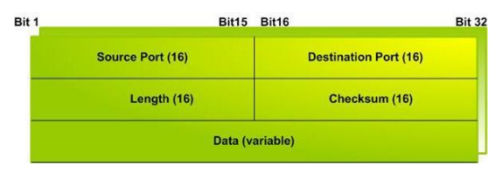

Napisz program, który z powyższego datagramu UDP wydobędzie:
- numer źródłowego portu
- numer docelowego portu
- dane (ile bajtów w tym pakiecie zajmują dane?)
A następnie uzyskany wynik w postaci:
```
zad14odp;src;X;dst;Y;data;Z
```
gdzie:
- X to wydobyty z pakietu numer portu źródłowego
- Y to wydobyty z pakietu numer portu docelowego
- Z to wydobyte z pakietu dane

Prześle do serwera UDP działającego na porcie numer 2910 pod adresem 212.182.24.27 w celu sprawdzenia,
czy udało się prawidłowo odczytać wymagane pola. Serwer zwróci odpowiedź -> TAK lub NIE, a w przypadku
błędnego sformatowania wiadomości, odeśle odpowiedź BAD SYNTAX.

In [ ]:
def hex_to_decimal(hex_str):
    return int(hex_str, 16)


def hex_to_text(hex_str):
    return bytes.fromhex(hex_str).decode("utf-8")


def from_udp_datagram(udp_datagram: str) -> Dict[str, str]:
    src_port = hex_to_decimal(udp_datagram[0:4])
    dst_port = hex_to_decimal(udp_datagram[4:8])
    length = hex_to_decimal(udp_datagram[8:12])
    checksum = hex_to_decimal(udp_datagram[12:16])
    data = hex_to_text(udp_datagram[16:])
    return {"src_port": src_port, "dst_port": dst_port, "length": length, "checksum": checksum, "data": data}


if __name__ == "__main__":
    sockIPv4 = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)

    datagram = "ed740b550024effd70726f6772616d6d696e6720696e20707974686f6e2069732066756e"
    decoded_data = from_udp_datagram(datagram)

    X = decoded_data["src_port"]
    Y = decoded_data["dst_port"]
    DATA = decoded_data["data"]
    print(X, Y, DATA)

    try:
        sockIPv4.connect(('127.0.0.1', 2909))

        sockIPv4.send(f"zad14odp;src;{X};dst;{Y};data;{DATA}".encode())
        print(sockIPv4.recv(1024))
    except socket.error as exc:
        print(f"Error {exc}")

    print("Closing")
    sockIPv4.close()


Poniżej znajduje się pełny zapis segmentu TCP w postaci szesnastkowej (pole opcji ma 12 bajtów).
```
0b 54 89 8b 1f 9a 18 ec bb b1 64 f2 80 18
00 e3 67 71 00 00 01 01 08 0a 02 c1 a4 ee
00 1a 4c ee 68 65 6c 6c 6f 20 3a 29
```
Wiedząc, że w zapisie szesnastkowym jedna cyfra reprezentuje 4 bity, oraz znając strukturę segmentu TCP:
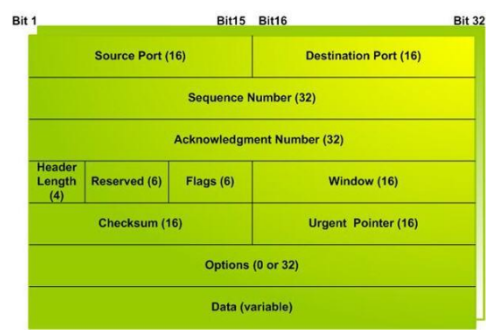

Napisz program, który z powyższego segmentu TCP wydobędzie:
- numer źródłowego portu
- numer docelowego portu
- dane (ile bajtów w tym pakiecie zajmują dane?)

A następnie uzyskany wynik w postaci:
```
zad13odp;src;X;dst;Y;data;Z
```
gdzie:
- X to wydobyty z pakietu numer portu źródłowego
- Y to wydobyty z pakietu numer portu docelowego
- Z to wydobyte z pakietu dane

Prześle do serwera UDP działającego na porcie numer 2909 pod adresem 212.182.24.27 w celu sprawdzenia,
czy udało się prawidłowo odczytać wymagane pola. Serwer zwróci odpowiedź -> TAK lub NIE, a w przypadku
błędnego sformatowania wiadomości, odeśle odpowiedź BAD SYNTAX.

In [30]:
def binary_to_decimal(bin_str):
    return int(bin_str, 2)


def binary_to_hex(binary_str):
    decimal_value = int(binary_str, 2)
    hex_str = hex(decimal_value)[2:].upper()
    return hex_str


def hex_to_text(hex_str):
    clean_hex = ''.join(c for c in hex_str if c in "0123456789abcdefABCDEF")
    if len(clean_hex) % 2 != 0:
        clean_hex = '0' + clean_hex
    return bytes.fromhex(clean_hex).decode("utf-8", errors="replace")


def hex_to_binary(hex_str):
    clean_hex = ''.join(c for c in hex_str if c in "0123456789abcdefABCDEF")
    return ''.join(format(int(c, 16), '04b') for c in clean_hex)


def from_tcp_datagram(tcp_hex_datagram: str):
    tcp_hex_datagram = tcp_hex_datagram.lstrip("0b")
    tcp_binary_datagram = hex_to_binary(tcp_hex_datagram)

    return {
        "src_port": binary_to_decimal(tcp_binary_datagram[0:16]),
        "dst_port": binary_to_decimal(tcp_binary_datagram[16:32]),
        "sequence_number": binary_to_decimal(tcp_binary_datagram[32:64]),
        "ack_number": binary_to_decimal(tcp_binary_datagram[64:96]),
        "header_length": binary_to_decimal(tcp_binary_datagram[96:100]),
        "reserved": binary_to_decimal(tcp_binary_datagram[100:106]),
        "flags": binary_to_decimal(tcp_binary_datagram[106:112]),
        "window": binary_to_decimal(tcp_binary_datagram[112:128]),
        "checksum": binary_to_decimal(tcp_binary_datagram[128:144]),
        "urgent_pointer": binary_to_decimal(tcp_binary_datagram[144:160]),
        "data": hex_to_text(binary_to_hex(tcp_binary_datagram[192:])),
    }


if __name__ == "__main__":
    # TODO: NIC NIE DZIALA RAAAH
    sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)

    datagram = "0b54898b1f9a18ecbbb164f2801800e3677100000101080a02c1a4ee001a4cee68656c6c6f203a29"

    decoded = from_tcp_datagram(datagram)

    X = decoded["src_port"]
    Y = decoded["dst_port"]
    DATA = decoded["data"]

    print(X, Y, DATA)

    try:
        sock.connect(("127.0.0.1", 2910))
        sock.send(f"zad14odp;src;{X};dst;{Y};data;{DATA}".encode())
        print(sock.recv(1024))
    except socket.error as e:
        print(f"Error {e}")
    finally:
        sock.close()


21641 35615 ��� L�hello :)
b'NIE'


15. Poniżej znajduje się pełny zapis pakietu IP w postaci szesnastkowej (bez pola opcji IP, jeśli protokół to
TCP, pole opcji TCP ma 12 bajtów).
```
45 00 00 4e f7 fa 40 00 38 06 9d 33 d4 b6 18 1b
c0 a8 00 02 0b 54 b9 a6 fb f9 3c 57 c1 0a 06 c1
80 18 00 e3 ce 9c 00 00 01 01 08 0a 03 a6 eb 01
00 0b f8 e5 6e 65 74 77 6f 72 6b 20 70 72 6f 67
72 61 6d 6d 69 6e 67 20 69 73 20 66 75 6e
```

Wiedząc, że w zapisie szesnastkowym jedna cyfra reprezentuje 4 bity, oraz znając strukturę pakietu IP
(tu IP/TCP):
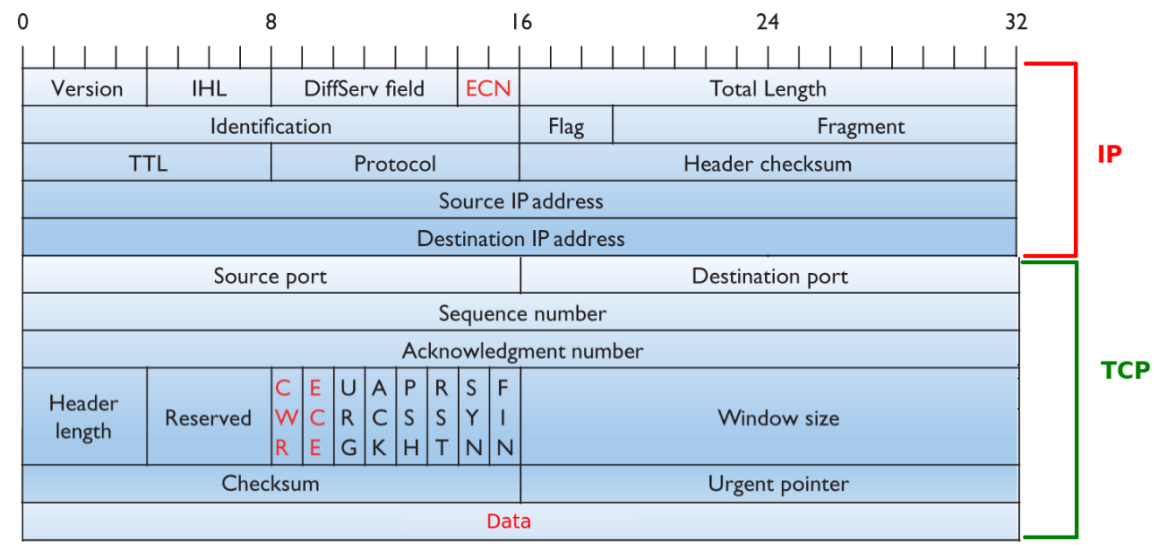

Napisz program, który z powyższego pakietu IP wydobędzie:
- wersję protokołu
- źródłowy adres IP
- docelowy adres IP
- typ protokołu warstwy wyższej:
  - Numer protokołu TCP w polu Protocol nagłówka IPv4 to 6 (0x06)
  - Numer protokołu UDP w polu Protocol nagłówka IPv4 to 17 (0x11)

Oraz, po określeniu typu protokołu (TCP/UDP) dodatkowo wydobędzie z pakietu:
- numer źródłowego portu
- numer docelowego portu
- dane (ile bajtów w tym pakiecie zajmują dane?)

Następnie, w celu sprawdzenia, czy udało się prawidłowo odczytać wymagane pola, wyśle do serwera UDP działającego na porcie numer 2911 pod adresem 212.182.24.27 dwie wiadomości. Serwer zwróci odpowiedź -> TAK lub NIE, a w przypadku błędnego sformatowania wiadomości, odeśle odpowiedź BAD SYNTAX.

Prawidłowy protokół powinien wyglądać w następujący sposób:
(a) Klient wysyła do serwera wiadomość w postaci:
```
zad15odpA;ver;X;srcip;Y;dstip;Z;type;W
```
gdzie:
- X to wydobyty z pakietu numer wersji protokołu
- Y to wydobyty z pakietu źródłowy adres IP
- Z to wydobyty z pakietu docelowy adres IP
- W to wydobyty z pakietu typ protokołu warstwy wyższej (numer)

(b) Klient odbiera od serwera wiadomość, która mówi o tym, czy odpowiedź jest prawidłowa, czy nie
(c) Jeśli klient otrzyma od serwera odpowiedź TAK, może wysłać kolejną wiadomość do sprawdzenia w
postaci:
```
zad15odpB;srcport;X;dstport;Y;data;Z
```
gdzie:
- X to wydobyty z pakietu numer portu źródłowego
- Y to wydobyty z pakietu numer portu docelowego
- Z to wydobyte z pakietu dane

(d) Klient odbiera od serwera wiadomość, która mówi o tym, czy odpowiedź jest prawidłowa, czy nie

16. Po wykonaniu zadań 13 - 15, spróbuj jeszcze raz uruchomić klientów, wykorzystując dane zawarte w pakietach. Jednocześnie za pomocą Wiresharka podsłuchuj pakiety i podejrzyj ich zawartość.